In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
MAX_ITER = 10000

<h3>Rosenbrock Function and Gradient

In [2]:
def rosenbrock(x, y, a=1, b=100):
    return (a - x)**2 + b * (y - x**2)**2

In [3]:
def rosenbrock_gradient(x, y, a=1, b=100):
    dx = 2 * (x - a) - 4 * b * x * (y - x**2)
    dy = 2 * b * (y - x**2)

    return np.array([dx, dy])

<h3>Ackley Function and Gradient

In [4]:
def ackley(x):
    if np.isclose(x, 0):
        return 0.0

    return -20 * np.exp(-0.2 * np.sqrt(x**2)) \
           - np.exp(np.cos(2 * np.pi * x)) \
           + 20 + np.e

In [5]:
def ackley_gradient(x):
    if np.isclose(x, 0):
        return 0.0

    sqrt_term = np.sqrt(x**2)

    term1 = 4 * x / sqrt_term * np.exp(-0.2 * sqrt_term)

    term2 = 2 * np.pi * np.sin(2 * np.pi * x) * \
            np.exp(np.cos(2 * np.pi * x))

    return term1 + term2

<h3>Visualization of Rosenbrock

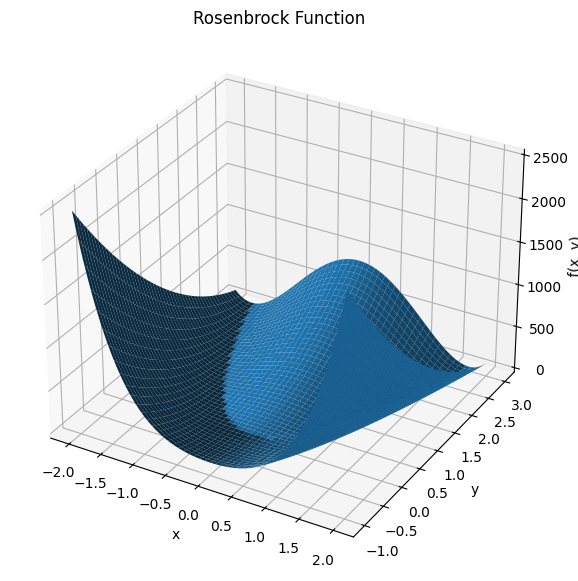

In [6]:
from mpl_toolkits.mplot3d import Axes3D

x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)

X, Y = np.meshgrid(x, y)

Z = rosenbrock(X, Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.set_title("Rosenbrock Function")

plt.show()

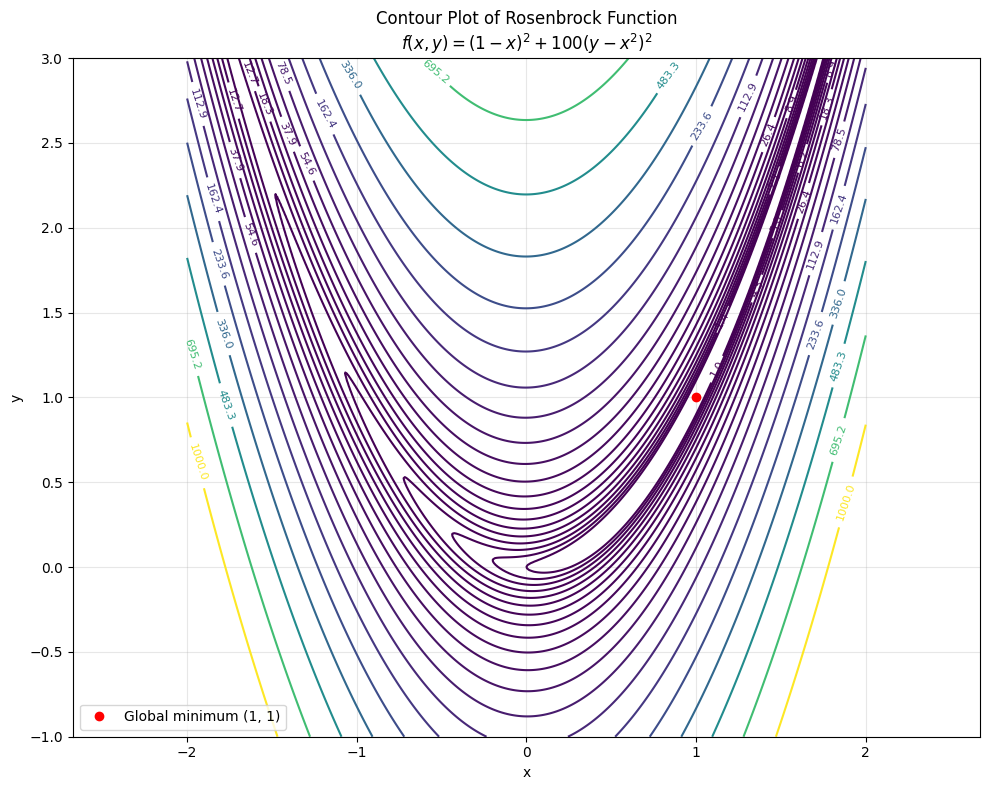

In [7]:
x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = rosenbrock(X, Y)

plt.figure(figsize=(10, 8))
contours = plt.contour(X, Y, Z, levels=np.logspace(0, 3, 20), cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)

plt.plot(1, 1, 'ro', label='Global minimum (1, 1)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Contour Plot of Rosenbrock Function\n$ f(x, y) = (1 - x)^2 + 100(y - x^2)^2 $')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

<h3>Basic GD

In [8]:
def gradient_descent(gradient_func, x0, learning_rate,
                     max_iter=MAX_ITER, tolerance=1e-8):
    x = np.array(x0, dtype=float)
    history = []
    for i in range(max_iter):
        gradient = gradient_func(*x) if x.ndim > 0 else gradient_func(x)
        x_new = x - learning_rate * gradient
        history.append(x_new.copy())
        if np.linalg.norm(x_new - x) < tolerance:
            break
        x = x_new
    return x, history, i + 1

<h3>Momentum

In [9]:
def momentum_optimizer(gradient_func, x0, learning_rate,
                       beta=0.9, max_iter=MAX_ITER, tolerance=1e-8):

    x = np.array(x0, dtype=float)
    velocity = np.zeros_like(x)
    history = []
    for i in range(max_iter):
        gradient = gradient_func(*x) if x.ndim > 0 else gradient_func(x)
        velocity = beta * velocity + gradient
        x_new = x - learning_rate * velocity
        history.append(x_new.copy())
        if np.linalg.norm(x_new - x) < tolerance:
            break
        x = x_new
    return x, history, i + 1

<h3>RMS Propagation

In [10]:
def rmsprop_optimizer(gradient_func, x0, learning_rate,
                      beta=0.9, epsilon=1e-8,
                      max_iter=MAX_ITER, tolerance=1e-8):
    x = np.array(x0, dtype=float)
    squared_gradient = np.zeros_like(x)
    history = []
    for i in range(max_iter):
        gradient = gradient_func(*x) if x.ndim > 0 else gradient_func(x)
        squared_gradient = (
            beta * squared_gradient
            + (1 - beta) * gradient**2
        )
        x_new = x - learning_rate * gradient / (
            np.sqrt(squared_gradient) + epsilon
        )
        history.append(x_new.copy())
        if np.linalg.norm(x_new - x) < tolerance:
            break
        x = x_new
    return x, history, i + 1

<h3>Adagrad

In [11]:
def adagrad_optimizer(gradient_func, x0, learning_rate,
                      epsilon=1e-8,
                      max_iter=MAX_ITER, tolerance=1e-8):

    x = np.array(x0, dtype=float)
    accumulated_gradient = np.zeros_like(x)

    history = []
    for i in range(max_iter):
        gradient = gradient_func(*x) if x.ndim > 0 else gradient_func(x)
        accumulated_gradient += gradient**2
        x_new = x - learning_rate * gradient / (
            np.sqrt(accumulated_gradient) + epsilon
        )
        history.append(x_new.copy())
        if np.linalg.norm(x_new - x) < tolerance:
            break
        x = x_new
    return x, history, i + 1

<h3>Adam

In [12]:
def adam_optimizer(gradient_func, x0, learning_rate,
                   beta1=0.9, beta2=0.999,
                   epsilon=1e-8,
                   max_iter=MAX_ITER, tolerance=1e-8):
    x = np.array(x0, dtype=float)
    m = np.zeros_like(x)
    v = np.zeros_like(x)
    history = []
    for i in range(1, max_iter + 1):
        gradient = gradient_func(*x) if x.ndim > 0 else gradient_func(x)
        m = beta1 * m + (1 - beta1) * gradient
        v = beta2 * v + (1 - beta2) * gradient**2

        m_hat = m / (1 - beta1**i)
        v_hat = v / (1 - beta2**i)
        x_new = x - learning_rate * m_hat / (
            np.sqrt(v_hat) + epsilon
        )
        history.append(x_new.copy())
        if np.linalg.norm(x_new - x) < tolerance:
            break
        x = x_new
    return x, history, i

<h3>Convergence plot grid

In [13]:
def plot_convergence_grid(gradient_func, func, x0, optimizers, learning_rates,
                            title_prefix, is_2d=False, save_name=None):

    fig, axes = plt.subplots(nrows=len(learning_rates), ncols=len(optimizers),
                              figsize=(4*len(optimizers), 3.5*len(learning_rates)),
                              sharex=True)

    if len(learning_rates) == 1:
        axes = axes.reshape(1, -1)

    for i, lr in enumerate(learning_rates):
        for j, (optimizer_name, optimizer) in enumerate(optimizers.items()):
            ax = axes[i, j]
            try:
                result, history, iterations = optimizer(
                    gradient_func, x0, learning_rate=lr, max_iter=MAX_ITER
                )
                if is_2d:
                    losses = [func(p[0], p[1]) for p in history]
                else:
                    losses = [func(p[0]) for p in history]
                losses = np.array(losses)
                running_min = np.minimum.accumulate(losses)
                ax.plot(losses, color='steelblue', alpha=0.25, linewidth=0.6,
                         label='Raw value')

                ax.plot(running_min, color='crimson', linewidth=1.6,
                         label='Best-so-far')
                ax.set_yscale("log")
                y_lo = max(running_min.min(), 1e-12)
                y_hi = np.percentile(losses, 95)
                ax.set_ylim(y_lo * 0.5, y_hi * 1.5)
            except Exception as e:
                ax.text(0.5, 0.5, f"Diverged/Error", ha='center', va='center',
                        transform=ax.transAxes, color='red')

            ax.set_title(f"{optimizer_name} (LR={lr})", fontsize=9)
            ax.grid(True, which="both", linestyle="--", alpha=0.3)
            if j == 0:
                ax.set_ylabel("Function Value")
            if i == len(learning_rates) - 1:
                ax.set_xlabel("Iteration")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))

    fig.suptitle(f"{title_prefix} Convergence Comparison", y=1.05)
    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

<h3>Optimizers

In [14]:
optimizers = {
    "Gradient Descent": gradient_descent,
    "Momentum": momentum_optimizer,
    "RMSprop": rmsprop_optimizer,
    "Adagrad": adagrad_optimizer,
    "Adam": adam_optimizer
}

learning_rates = [0.01, 0.05, 0.1]

<h3>Rosenbrock Experiments

In [15]:
results = []

x0 = np.array([-1.5, 2.0])

for optimizer_name, optimizer in optimizers.items():

    for lr in learning_rates:

        start = time.time()

        try:
            result, history, iterations = optimizer(
                rosenbrock_gradient,
                x0,
                learning_rate=lr
            )

            elapsed_time = time.time() - start

            final_value = rosenbrock(*result)

            converged = iterations < MAX_ITER
            is_finite = np.isfinite(final_value)

            if converged and is_finite:
                status = "Converged"
            elif is_finite:
                status = "Hit max_iter (not converged)"
            else:
                status = "Diverged"

            results.append({
                "Optimizer": optimizer_name,
                "Learning Rate": lr,
                "x": result[0],
                "y": result[1],
                "f(x,y)": final_value,
                "Iterations": iterations,
                "Time (s)": elapsed_time,
                "Status": status
            })

        except Exception as e:

            results.append({
                "Optimizer": optimizer_name,
                "Learning Rate": lr,
                "x": np.nan,
                "y": np.nan,
                "f(x,y)": np.nan,
                "Iterations": np.nan,
                "Time (s)": np.nan,
                "Status": f"Error: {e}"
            })

rosenbrock_results = pd.DataFrame(results)
rosenbrock_results.to_csv("rosenbrock_results.csv", index=False)
print(f"Saved {len(rosenbrock_results)} rows to rosenbrock_results.csv")

/tmp/ipykernel_1316/3175139746.py:2: RuntimeWarning: overflow encountered in scalar power
  dx = 2 * (x - a) - 4 * b * x * (y - x**2)
/tmp/ipykernel_1316/3175139746.py:3: RuntimeWarning: overflow encountered in scalar power
  dy = 2 * b * (y - x**2)
/tmp/ipykernel_1316/3175139746.py:2: RuntimeWarning: invalid value encountered in scalar subtract
  dx = 2 * (x - a) - 4 * b * x * (y - x**2)
/tmp/ipykernel_1316/3175139746.py:3: RuntimeWarning: invalid value encountered in scalar subtract
  dy = 2 * b * (y - x**2)
/tmp/ipykernel_1316/3175139746.py:2: RuntimeWarning: overflow encountered in scalar multiply
  dx = 2 * (x - a) - 4 * b * x * (y - x**2)
/tmp/ipykernel_1316/1439000911.py:7: RuntimeWarning: invalid value encountered in subtract
  x_new = x - learning_rate * gradient
/tmp/ipykernel_1316/3816871209.py:9: RuntimeWarning: invalid value encountered in add
  velocity = beta * velocity + gradient


Saved 15 rows to rosenbrock_results.csv


<h3>Rosenbrock Convergence Plots

/tmp/ipykernel_1316/3175139746.py:2: RuntimeWarning: overflow encountered in scalar power
  dx = 2 * (x - a) - 4 * b * x * (y - x**2)
/tmp/ipykernel_1316/3175139746.py:3: RuntimeWarning: overflow encountered in scalar power
  dy = 2 * b * (y - x**2)
/tmp/ipykernel_1316/3175139746.py:2: RuntimeWarning: invalid value encountered in scalar subtract
  dx = 2 * (x - a) - 4 * b * x * (y - x**2)
/tmp/ipykernel_1316/3175139746.py:3: RuntimeWarning: invalid value encountered in scalar subtract
  dy = 2 * b * (y - x**2)


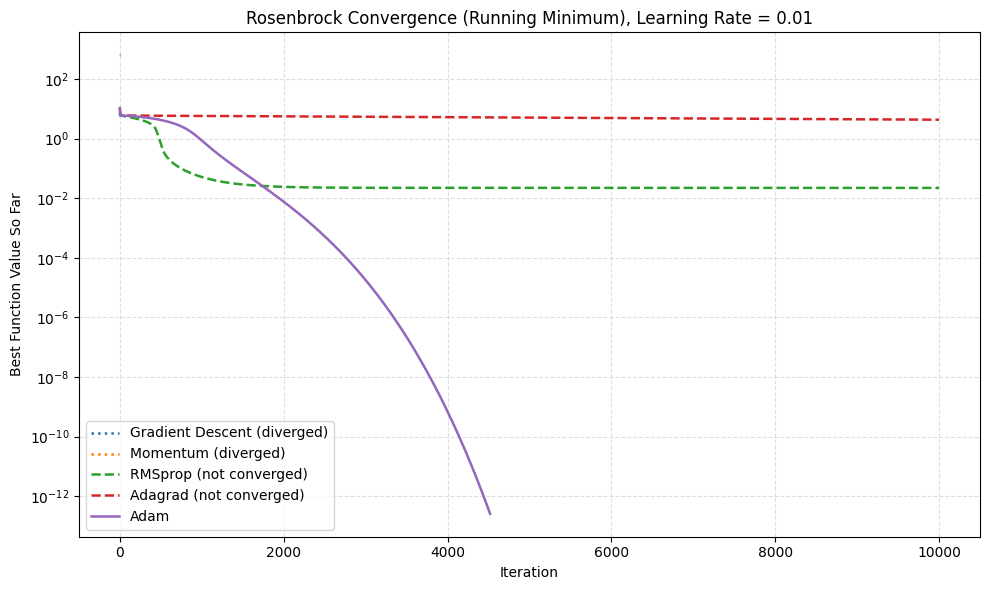

/tmp/ipykernel_1316/3175139746.py:2: RuntimeWarning: overflow encountered in scalar multiply
  dx = 2 * (x - a) - 4 * b * x * (y - x**2)
/tmp/ipykernel_1316/1439000911.py:7: RuntimeWarning: invalid value encountered in subtract
  x_new = x - learning_rate * gradient
/tmp/ipykernel_1316/3816871209.py:9: RuntimeWarning: invalid value encountered in add
  velocity = beta * velocity + gradient


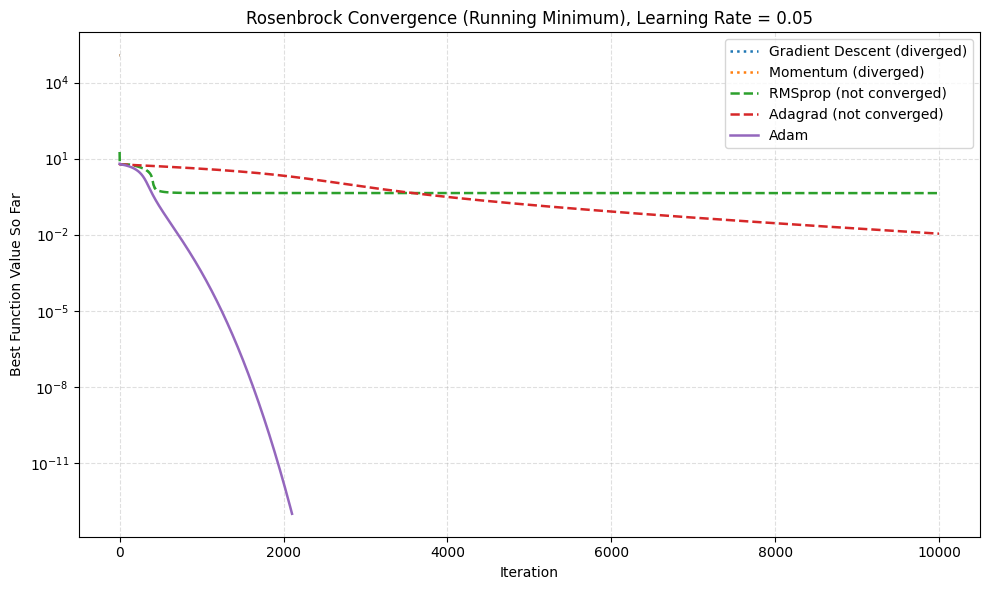

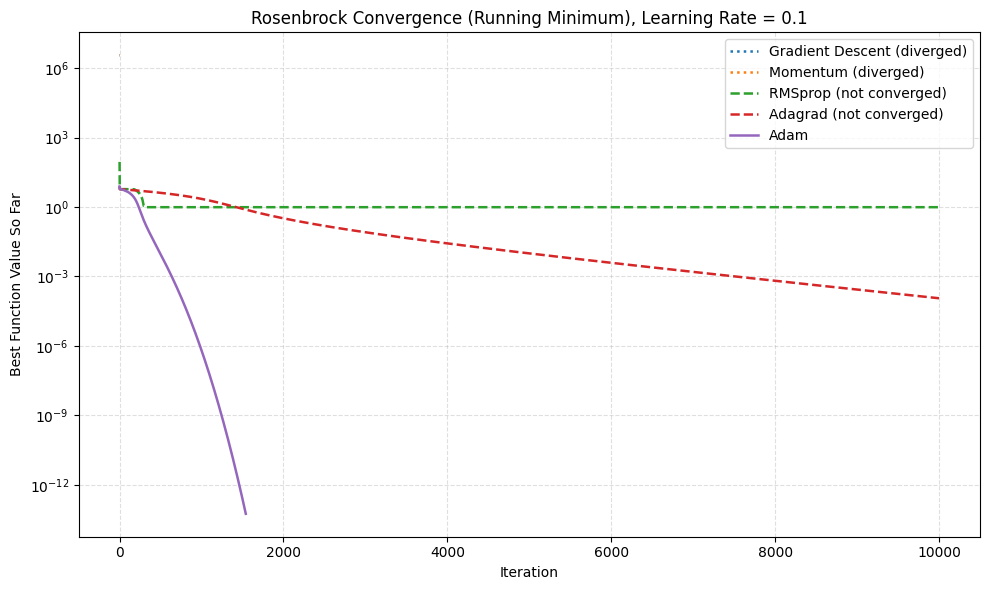

In [16]:
x0 = np.array([-1.5, 2.0])

for lr in learning_rates:

    plt.figure(figsize=(10, 6))

    for optimizer_name, optimizer in optimizers.items():

        try:
            result, history, iterations = optimizer(
                rosenbrock_gradient,
                x0,
                learning_rate=lr,
                max_iter=MAX_ITER
            )

            losses = np.array([
                rosenbrock(point[0], point[1])
                for point in history
            ])

            running_min = np.minimum.accumulate(losses)

            converged = iterations < MAX_ITER
            is_finite = np.isfinite(running_min[-1])

            if converged and is_finite:
                label = f"{optimizer_name}"
                linestyle = '-'
            elif is_finite:
                label = f"{optimizer_name} (not converged)"
                linestyle = '--'
            else:
                label = f"{optimizer_name} (diverged)"
                linestyle = ':'

            plt.plot(running_min, label=label, linestyle=linestyle, linewidth=1.8)

        except Exception:
            plt.plot([], label=f"{optimizer_name} (error)")

    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Best Function Value So Far")
    plt.title(f"Rosenbrock Convergence (Running Minimum), Learning Rate = {lr}")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"rosenbrock_convergence_lr{lr}.png", dpi=150)
    plt.show()

/tmp/ipykernel_1316/3175139746.py:2: RuntimeWarning: overflow encountered in scalar power
  dx = 2 * (x - a) - 4 * b * x * (y - x**2)
/tmp/ipykernel_1316/3175139746.py:3: RuntimeWarning: overflow encountered in scalar power
  dy = 2 * b * (y - x**2)
/tmp/ipykernel_1316/3175139746.py:2: RuntimeWarning: invalid value encountered in scalar subtract
  dx = 2 * (x - a) - 4 * b * x * (y - x**2)
/tmp/ipykernel_1316/3175139746.py:3: RuntimeWarning: invalid value encountered in scalar subtract
  dy = 2 * b * (y - x**2)
/tmp/ipykernel_1316/3175139746.py:2: RuntimeWarning: overflow encountered in scalar multiply
  dx = 2 * (x - a) - 4 * b * x * (y - x**2)
/tmp/ipykernel_1316/1439000911.py:7: RuntimeWarning: invalid value encountered in subtract
  x_new = x - learning_rate * gradient
/tmp/ipykernel_1316/3816871209.py:9: RuntimeWarning: invalid value encountered in add
  velocity = beta * velocity + gradient


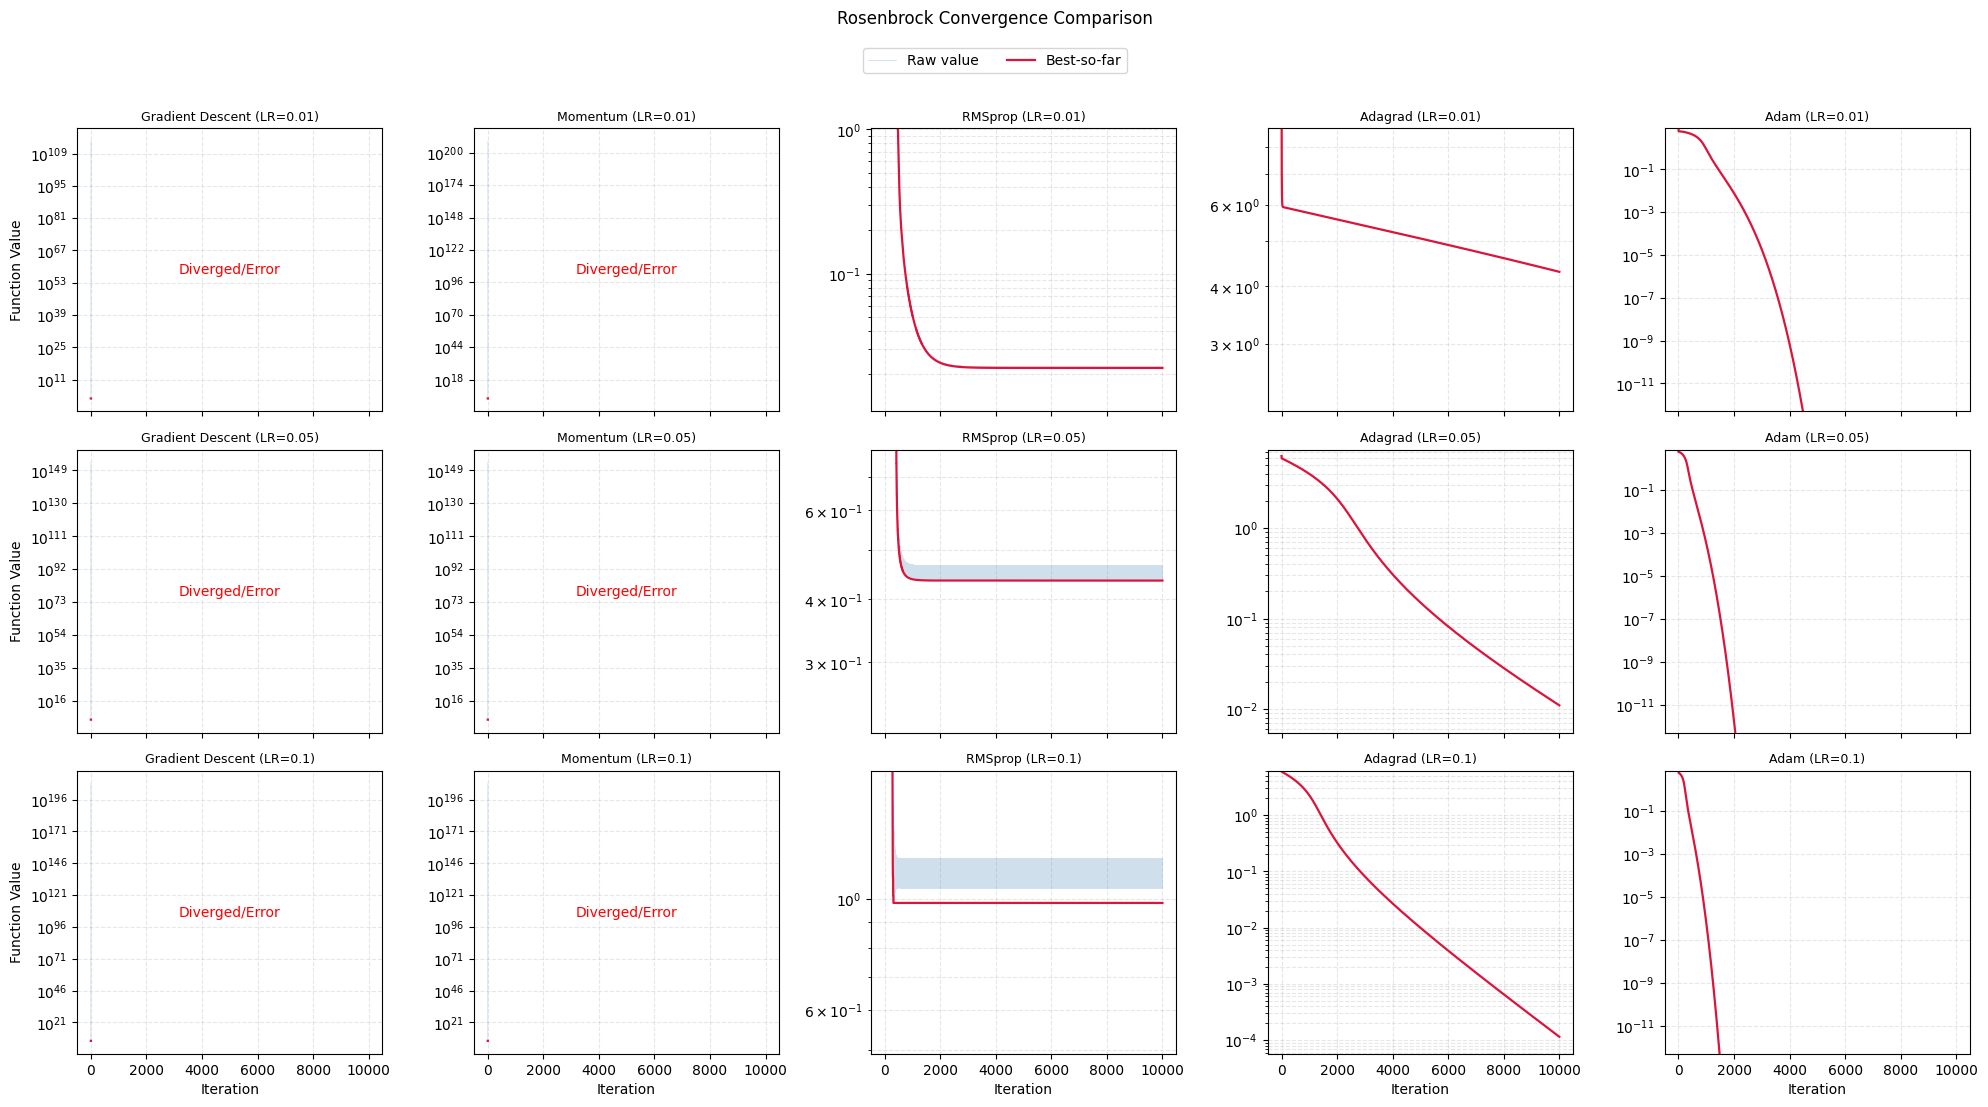

In [17]:
plot_convergence_grid(
    rosenbrock_gradient, rosenbrock, np.array([-1.5, 2.0]),
    optimizers, learning_rates,
    title_prefix="Rosenbrock", is_2d=True,
    save_name="rosenbrock_convergence_clean.png"
)


<h3>Ackley experiments

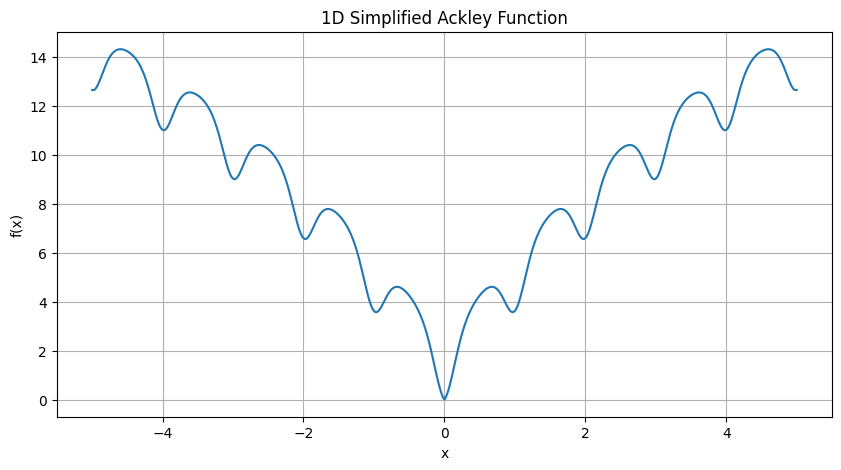

In [18]:
x = np.linspace(-5, 5, 1000)

y = np.array([ackley(value) for value in x])

plt.figure(figsize=(10, 5))

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("1D Simplified Ackley Function")

plt.grid()
plt.show()

In [19]:
results = []

x0 = np.array([2.3])

for optimizer_name, optimizer in optimizers.items():

    for lr in learning_rates:

        start = time.time()

        try:
            result, history, iterations = optimizer(
                ackley_gradient,
                x0,
                learning_rate=lr
            )

            elapsed_time = time.time() - start

            final_value = ackley(result[0])

            converged = iterations < MAX_ITER
            is_finite = np.isfinite(final_value)

            if converged and is_finite:
                status = "Converged"
            elif is_finite:
                status = "Hit max_iter (not converged)"
            else:
                status = "Diverged"

            results.append({
                "Optimizer": optimizer_name,
                "Learning Rate": lr,
                "x": result[0],
                "f(x)": final_value,
                "Iterations": iterations,
                "Time (s)": elapsed_time,
                "Status": status
            })

        except Exception as e:

            results.append({
                "Optimizer": optimizer_name,
                "Learning Rate": lr,
                "x": np.nan,
                "f(x)": np.nan,
                "Iterations": np.nan,
                "Time (s)": np.nan,
                "Status": f"Error: {e}"
            })

ackley_results = pd.DataFrame(results)
ackley_results.to_csv("ackley_results.csv", index=False)
print(f"Saved {len(ackley_results)} rows to ackley_results.csv")

Saved 15 rows to ackley_results.csv


<h3>Ackley Convergence

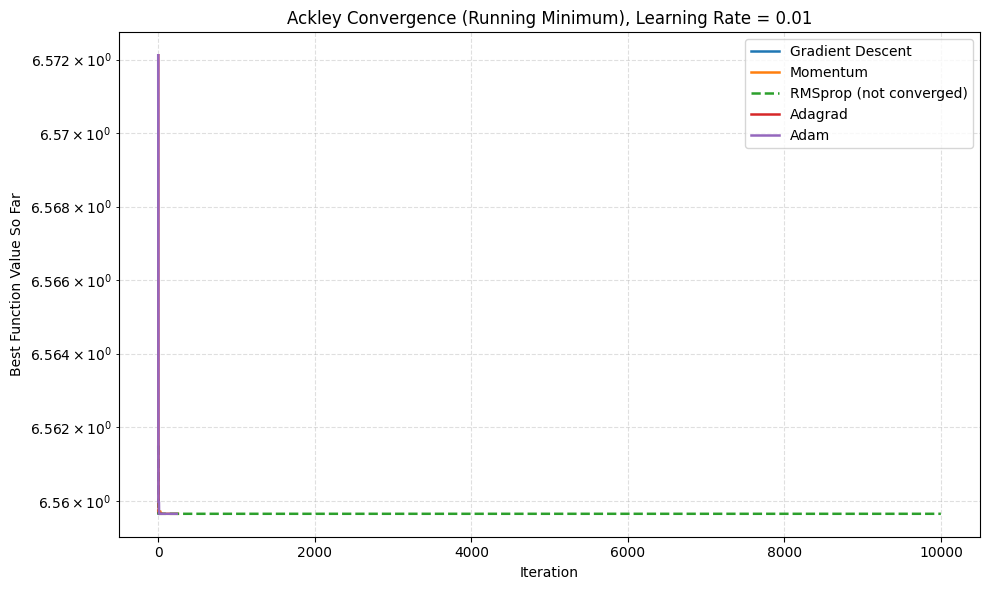

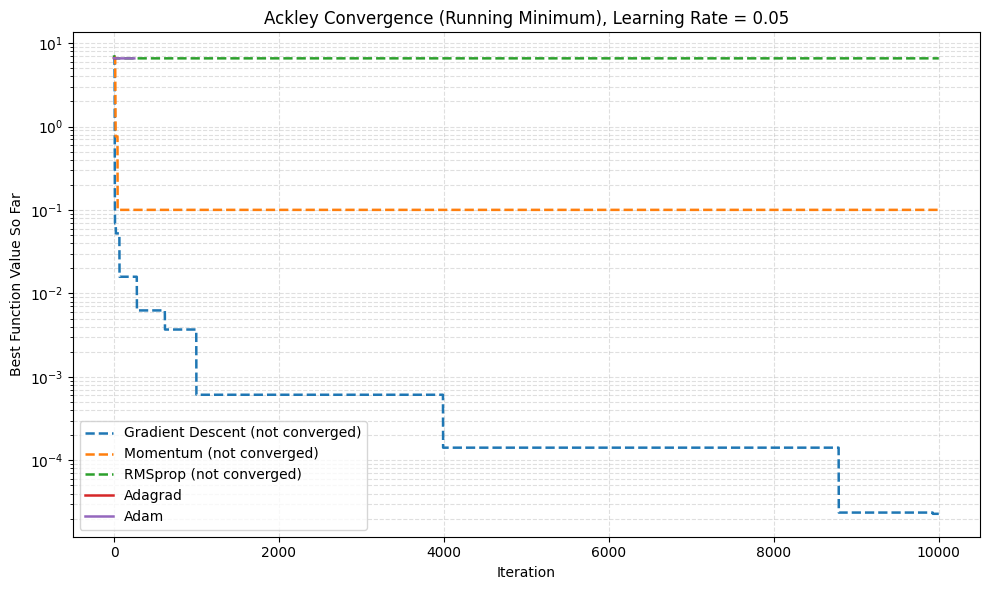

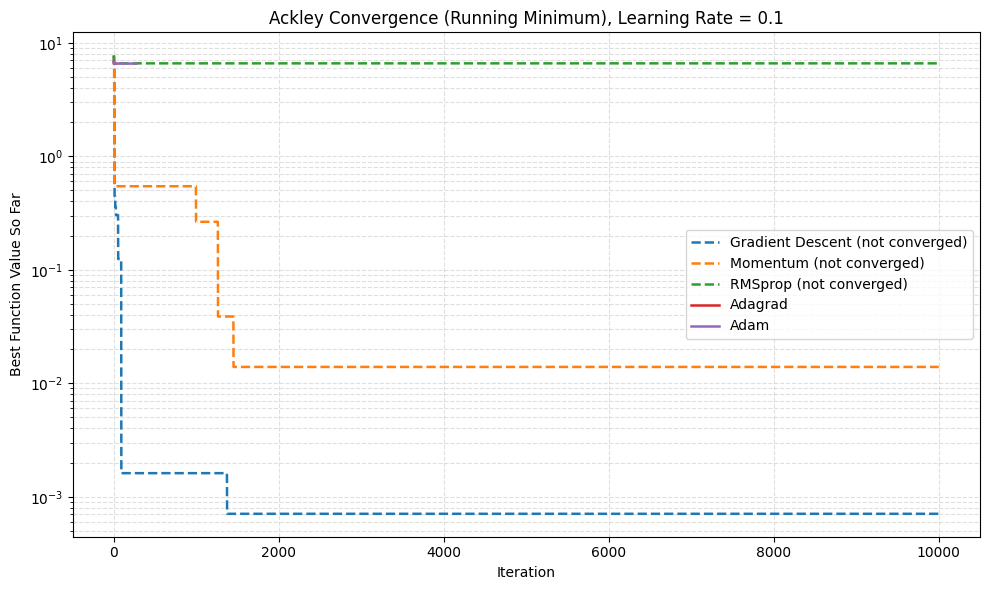

In [20]:
x0 = np.array([2.0])

for lr in learning_rates:

    plt.figure(figsize=(10, 6))

    for optimizer_name, optimizer in optimizers.items():

        try:
            result, history, iterations = optimizer(
                ackley_gradient,
                x0,
                learning_rate=lr,
                max_iter=MAX_ITER
            )

            losses = np.array([
                ackley(point[0])
                for point in history
            ])

            running_min = np.minimum.accumulate(losses)

            converged = iterations < MAX_ITER
            is_finite = np.isfinite(running_min[-1])

            if converged and is_finite:
                label = f"{optimizer_name}"
                linestyle = '-'
            elif is_finite:
                label = f"{optimizer_name} (not converged)"
                linestyle = '--'
            else:
                label = f"{optimizer_name} (diverged)"
                linestyle = ':'

            plt.plot(running_min, label=label, linestyle=linestyle, linewidth=1.8)

        except Exception:
            plt.plot([], label=f"{optimizer_name} (error)")

    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Best Function Value So Far")
    plt.title(f"Ackley Convergence (Running Minimum), Learning Rate = {lr}")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"ackley_convergence_lr{lr}.png", dpi=150)
    plt.show()

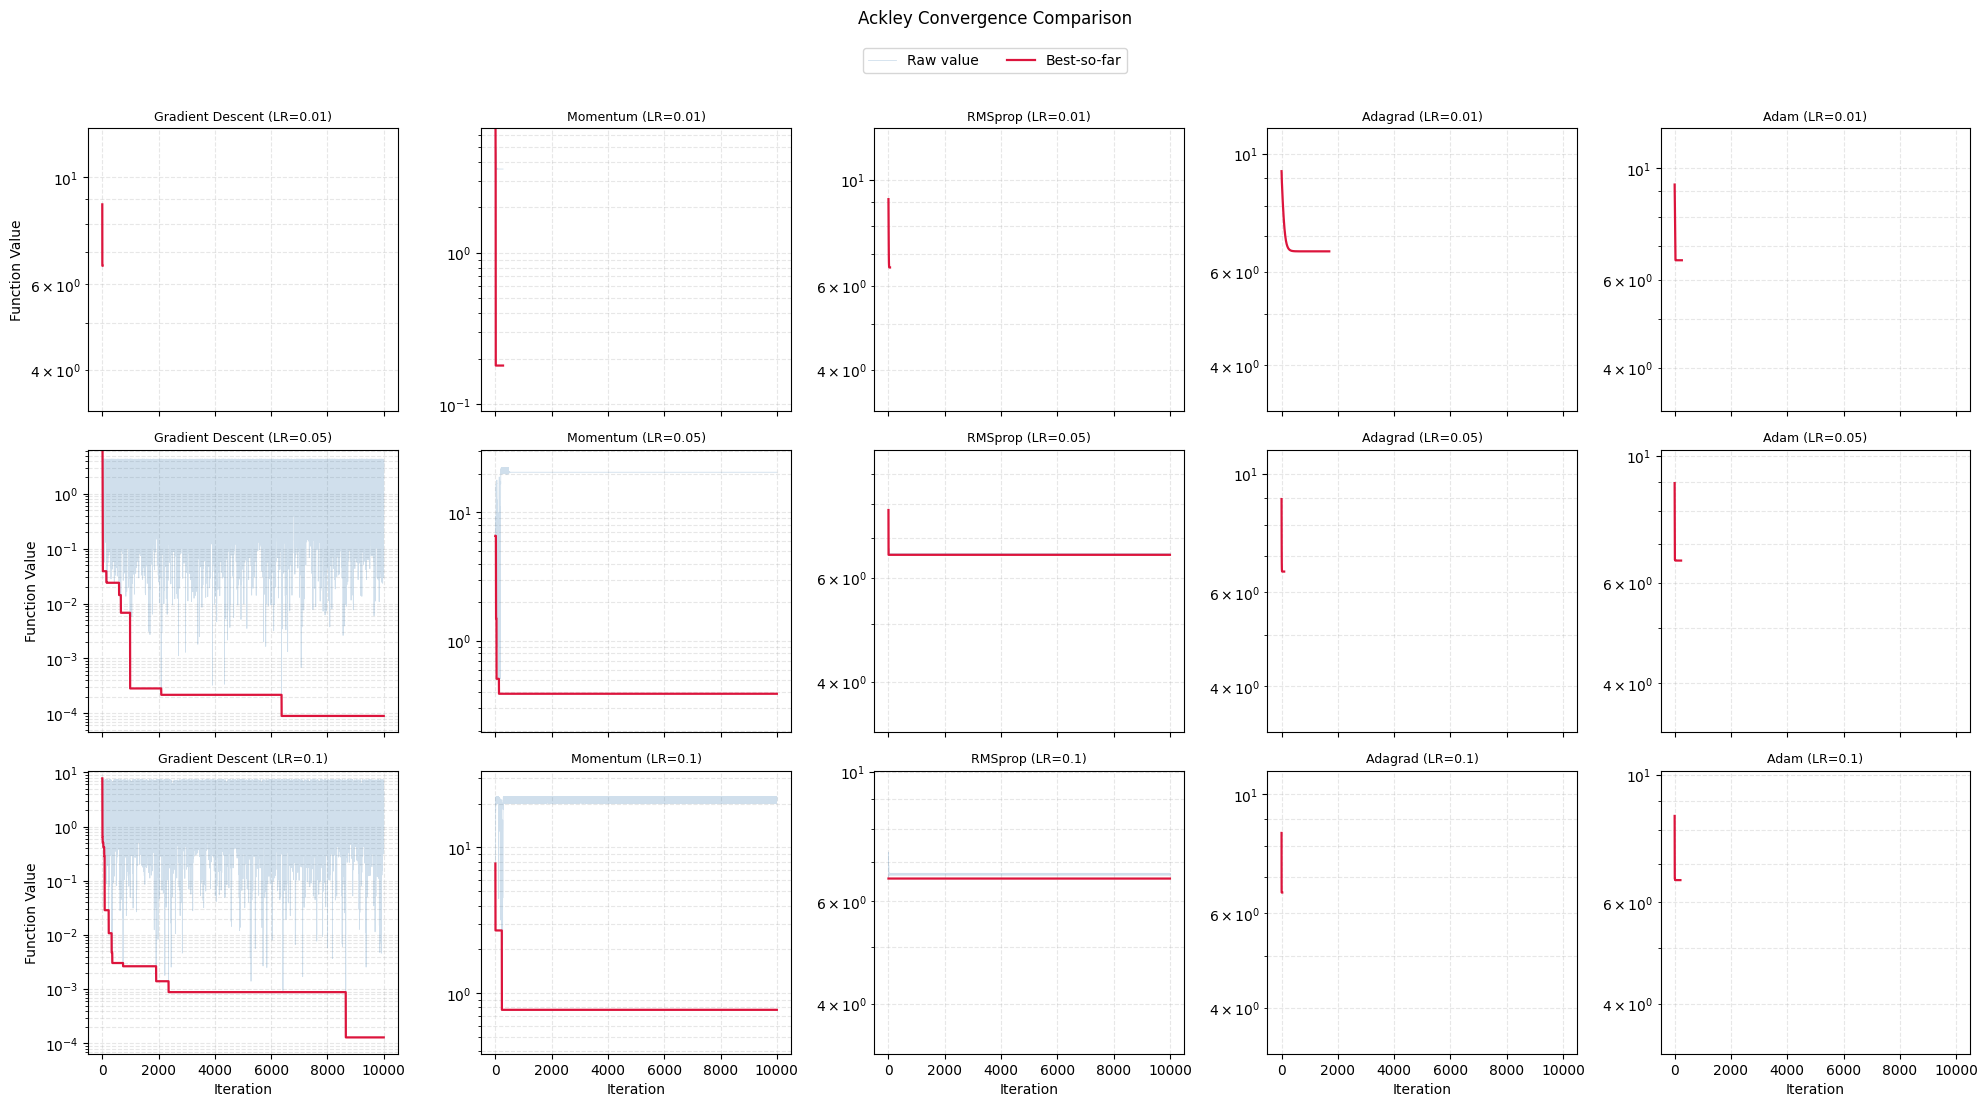

In [21]:
plot_convergence_grid(
    ackley_gradient, ackley, np.array([2.3]),
    optimizers, learning_rates,
    title_prefix="Ackley", is_2d=False,
    save_name="ackley_convergence_clean.png"
)

<h3>Comparing Learning Rates

In [22]:
for lr in learning_rates:

    subset = rosenbrock_results[
        rosenbrock_results["Learning Rate"] == lr
    ]

    print(f"\nLearning Rate = {lr}")
    print(subset[
        ["Optimizer", "x", "y", "f(x,y)", "Iterations", "Time (s)", "Status"]
    ].to_string(index=False))


Learning Rate = 0.01
       Optimizer         x        y       f(x,y)  Iterations  Time (s)                       Status
Gradient Descent       NaN      NaN          NaN       10000  0.189497                     Diverged
        Momentum       NaN      NaN          NaN       10000  0.119436                     Diverged
         RMSprop  0.980143 0.975531 2.245075e-02       10000  0.235398 Hit max_iter (not converged)
         Adagrad -1.071888 1.155444 4.296945e+00       10000  0.138383 Hit max_iter (not converged)
            Adam  0.999999 0.999999 2.623660e-13        4520  0.093615                    Converged

Learning Rate = 0.05
       Optimizer        x        y       f(x,y)  Iterations  Time (s)                       Status
Gradient Descent      NaN      NaN          NaN       10000  0.162823                     Diverged
        Momentum      NaN      NaN          NaN       10000  0.133364                     Diverged
         RMSprop 0.725000 0.465625 4.356250e-01       10000

In [23]:
for lr in learning_rates:

    subset = ackley_results[
        ackley_results["Learning Rate"] == lr
    ]

    print(f"\nLearning Rate = {lr}")
    print(subset[
        ["Optimizer", "x", "f(x)", "Iterations", "Time (s)", "Status"]
    ].to_string(index=False))


Learning Rate = 0.01
       Optimizer         x     f(x)  Iterations  Time (s)    Status
Gradient Descent  1.974452 6.559645           8  0.000836 Converged
        Momentum -0.968478 3.574452         273  0.008912 Converged
         RMSprop  1.974452 6.559645          56  0.003985 Converged
         Adagrad  1.974453 6.559645        1696  0.057251 Converged
            Adam  1.974451 6.559645         257  0.009553 Converged

Learning Rate = 0.05
       Optimizer          x      f(x)  Iterations  Time (s)                       Status
Gradient Descent  -0.246168  2.654742       10000  0.538408 Hit max_iter (not converged)
        Momentum -30.883541 20.572361       10000  0.282794 Hit max_iter (not converged)
         RMSprop   1.998115  6.588734       10000  0.342707 Hit max_iter (not converged)
         Adagrad   1.974452  6.559645          94  0.003393                    Converged
            Adam   1.974451  6.559645         230  0.008440                    Converged

Learning Rate

In [24]:
best_rosenbrock = rosenbrock_results[
    rosenbrock_results["Status"] == "Converged"
].loc[lambda df: df["f(x,y)"].idxmin()]

best_ackley = ackley_results[
    ackley_results["Status"] == "Converged"
].loc[lambda df: df["f(x)"].idxmin()]

print("Best Rosenbrock Result:")
print(best_rosenbrock)

print("\nBest Ackley Result:")
print(best_ackley)

Best Rosenbrock Result:
Optimizer             Adam
Learning Rate          0.1
x                      1.0
y                      1.0
f(x,y)                 0.0
Iterations            1541
Time (s)          0.033455
Status           Converged
Name: 14, dtype: object

Best Ackley Result:
Optimizer         Momentum
Learning Rate         0.01
x                -0.968478
f(x)              3.574452
Iterations             273
Time (s)          0.008912
Status           Converged
Name: 3, dtype: object


<h3>Extra analysis of robustness by changing starting points

In [25]:
starting_points_rb = [
    np.array([-1.5, 2.0]),
    np.array([0.0, 0.0]),
    np.array([2.0, -1.0]),
]

robustness_results_rb = []

for x0_start in starting_points_rb:
    for optimizer_name, optimizer in optimizers.items():
        for lr in learning_rates:

            try:
                result, history, iterations = optimizer(
                    rosenbrock_gradient,
                    x0_start,
                    learning_rate=lr
                )

                final_x, final_y = result[0], result[1]
                final_f = rosenbrock(final_x, final_y)

                converged = iterations < MAX_ITER
                is_finite = np.isfinite(final_f)

                if converged and is_finite:
                    status = "Converged"
                elif is_finite:
                    status = "Hit max_iter (not converged)"
                else:
                    status = "Diverged"

                robustness_results_rb.append({
                    "Starting Point": tuple(x0_start),
                    "Optimizer": optimizer_name,
                    "Learning Rate": lr,
                    "Final x": final_x,
                    "Final y": final_y,
                    "Final f(x,y)": final_f,
                    "Iterations": iterations,
                    "Status": status
                })

            except Exception as e:
                robustness_results_rb.append({
                    "Starting Point": tuple(x0_start),
                    "Optimizer": optimizer_name,
                    "Learning Rate": lr,
                    "Final x": np.nan,
                    "Final y": np.nan,
                    "Final f(x,y)": np.nan,
                    "Iterations": np.nan,
                    "Status": f"Error: {e}"
                })

rosenbrock_robustness = pd.DataFrame(robustness_results_rb)
rosenbrock_robustness.to_csv("rosenbrock_robustness.csv", index=False)

print(f"Saved {len(rosenbrock_robustness)} rows to rosenbrock_robustness.csv")

/tmp/ipykernel_1316/3175139746.py:2: RuntimeWarning: overflow encountered in scalar power
  dx = 2 * (x - a) - 4 * b * x * (y - x**2)
/tmp/ipykernel_1316/3175139746.py:3: RuntimeWarning: overflow encountered in scalar power
  dy = 2 * b * (y - x**2)
/tmp/ipykernel_1316/3175139746.py:2: RuntimeWarning: invalid value encountered in scalar subtract
  dx = 2 * (x - a) - 4 * b * x * (y - x**2)
/tmp/ipykernel_1316/3175139746.py:3: RuntimeWarning: invalid value encountered in scalar subtract
  dy = 2 * b * (y - x**2)
/tmp/ipykernel_1316/3175139746.py:2: RuntimeWarning: overflow encountered in scalar multiply
  dx = 2 * (x - a) - 4 * b * x * (y - x**2)
/tmp/ipykernel_1316/1439000911.py:7: RuntimeWarning: invalid value encountered in subtract
  x_new = x - learning_rate * gradient
/tmp/ipykernel_1316/3816871209.py:9: RuntimeWarning: invalid value encountered in add
  velocity = beta * velocity + gradient


Saved 45 rows to rosenbrock_robustness.csv


In [26]:
starting_points = [
    np.array([0.0]),
    np.array([0.3]),
    np.array([0.7]),
    np.array([1.5]),
    np.array([2.3]),
    np.array([-2.3]),
    np.array([3.5]),
]
robustness_results = []

for x0_start in starting_points:
    for optimizer_name, optimizer in optimizers.items():
        for lr in learning_rates:

            try:
                result, history, iterations = optimizer(
                    ackley_gradient,
                    x0_start,
                    learning_rate=lr
                )

                final_x = result[0]
                final_f = ackley(final_x)

                converged = iterations < MAX_ITER
                is_finite = np.isfinite(final_f)

                if converged and is_finite:
                    status = "Converged"
                elif is_finite:
                    status = "Hit max_iter (not converged)"
                else:
                    status = "Diverged"

                robustness_results.append({
                    "Starting Point": float(x0_start[0]),
                    "Optimizer": optimizer_name,
                    "Learning Rate": lr,
                    "Final x": final_x,
                    "Final f(x)": final_f,
                    "Iterations": iterations,
                    "Status": status
                })

            except Exception as e:
                robustness_results.append({
                    "Starting Point": float(x0_start[0]),
                    "Optimizer": optimizer_name,
                    "Learning Rate": lr,
                    "Final x": np.nan,
                    "Final f(x)": np.nan,
                    "Iterations": np.nan,
                    "Status": f"Error: {e}"
                })

ackley_robustness = pd.DataFrame(robustness_results)
ackley_robustness.to_csv("ackley_robustness.csv", index=False)
print(f"Saved {len(ackley_robustness)} rows to ackley_robustness.csv")

Saved 105 rows to ackley_robustness.csv


In [27]:
main_rb = rosenbrock_results.copy()
main_rb["Starting Point"] = [tuple(x0)] * len(main_rb)
main_rb = main_rb.rename(columns={"f(x,y)": "Final f(x,y)", "x": "Final x", "y": "Final y"})

combined_rb = pd.concat(
    [main_rb[["Starting Point","Optimizer","Learning Rate","Final x","Final y","Final f(x,y)","Iterations","Status"]],
     rosenbrock_robustness],
    ignore_index=True
)


converged_only_rb = combined_rb[combined_rb["Status"] == "Converged"]
best_rosenbrock_overall = converged_only_rb.loc[converged_only_rb["Final f(x,y)"].idxmin()]

print("\nBest Rosenbrock Result (across all starting points, converged runs only):")
print(best_rosenbrock_overall)



main_ackley = ackley_results.copy()
main_ackley["Starting Point"] = x0[0]
main_ackley = main_ackley.rename(columns={"f(x)": "Final f(x)", "x": "Final x"})

combined_ackley = pd.concat(
    [main_ackley[["Starting Point","Optimizer","Learning Rate","Final x","Final f(x)","Iterations","Status"]],
     ackley_robustness],
    ignore_index=True
)

converged_only_ackley = combined_ackley[combined_ackley["Status"] == "Converged"]
best_ackley_overall = converged_only_ackley.loc[converged_only_ackley["Final f(x)"].idxmin()]

print("\nBest Ackley Result (across all starting points, converged runs only):")
print(best_ackley_overall)


print("\nRosenbrock: best f(x,y) per starting point (converged only):")
print(
    converged_only_rb.groupby("Starting Point")["Final f(x,y)"].min()
)

print("\nAckley: best f(x) per starting point (converged only):")
print(
    converged_only_ackley.groupby("Starting Point")["Final f(x)"].min()
)


Best Rosenbrock Result (across all starting points, converged runs only):
Starting Point    (0.0, 0.0)
Optimizer               Adam
Learning Rate           0.01
Final x                  1.0
Final y                  1.0
Final f(x,y)             0.0
Iterations              1199
Status             Converged
Name: 42, dtype: object

Best Ackley Result (across all starting points, converged runs only):
Starting Point                 0.0
Optimizer         Gradient Descent
Learning Rate                 0.01
Final x                        0.0
Final f(x)                     0.0
Iterations                       1
Status                   Converged
Name: 15, dtype: object

Rosenbrock: best f(x,y) per starting point (converged only):
Starting Point
(-1.5, 2.0)    5.862918e-14
(0.0, 0.0)     2.726180e-14
(2.0,)         5.862918e-14
(2.0, -1.0)    3.532194e-13
Name: Final f(x,y), dtype: float64

Ackley: best f(x) per starting point (converged only):
Starting Point
-2.3    3.574452
 0.0    0.000000
